In [ ]:
!conda env export > environment.yml

In [ ]:
!conda env create -f environment.yml

In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import hddm
print(hddm.__version__)

HDDM: pytorch module seems missing. No LAN functionality can be loaded.
It seems that you do not have pytorch installed. You cannot use the network_inspector module.
It seems that you do not have pytorch installed.The HDDMnn, HDDMnnRegressor, HDDMnnStimCoding, HDDMnnRL and HDDMnnRLRegressorclasses will not work
It seems that you do not have pytorch installed.The HDDMnn, HDDMnnRegressor, HDDMnnStimCoding, HDDMnnRL and HDDMnnRLRegressorclasses will not work
It seems that you do not have pytorch installed.The HDDMnn, HDDMnnRegressor and HDDMnnStimCodingclasses will not work
It seems that you do not have pytorch installed.The HDDMnn, HDDMnnRL, HDDMnnRegressor, HDDMnnStimCoding, HDDMnnRL and HDDMnnRLRegressorclasses will not work
It seems that you do not have pytorch installed.The HDDMnn, HDDMnnRegressor, HDDMnnStimCoding, HDDMnnRL and HDDMnnRLRegressorclasses will not work
1.0.1


###やっていること

- participant_id列を、HDDMが要求するsubj_idx列にリネーム
- hddm.HDDM(data)で単純な（条件分けなしの）階層ドリフト拡散モデルを構築
- find_starting_values()で初期値探索 → sample()でMCMC推定
- print_stats() / plot_posteriors()で結果確認、m.save()でモデル保存

In [4]:
import hddm
import kabuki.hierarchical as _kh
from functools import reduce

def _flatten_fixed(l):
    return reduce(lambda x, y: list(x) + list(y), l, [])

_kh.flatten = _flatten_fixed  # hierarchical.py内で使われているflattenを差し替え

In [ ]:
#Data
data = pd.read_csv('../data/out.csv')

#前処理 
#参加者IDー＞subj_idxリネーム
data = data.rename(columns={"ResponseId": "subj_idx"}) #参照点無 ポジティブ
data = data.rename(columns={"F3_Page Submit": "rt"}) #送信ボタンで！！！！
data = data.rename(columns={"F4": "response"})

In [6]:
print(data.head())
print("n subjects:", data["subj_idx"].nunique())
print("n trials  :", len(data))

            subj_idx  1_Q3_First Click  1_Q3_Last Click  1_Q3_Page Submit  \
0  R_9c1VFY6zzn4WhDb             4.243            7.498             8.327   
1  R_9c1VFY6zzn4WhDb             3.929            5.406             6.647   
2  R_9c1VFY6zzn4WhDb             2.998            7.492             8.167   
3  R_9c1VFY6zzn4WhDb             2.764           10.881            11.577   
4  R_9c1VFY6zzn4WhDb             3.099            4.622             6.017   

   1_Q3_Click Count  1_Q4_1  1_Q5_1  2_Q3_First Click  2_Q3_Last Click  \
0                 2      29      71             6.794           16.803   
1                 2      28      62             2.730            4.291   
2                 4      29      66             4.000            5.880   
3                 7      37      61             2.698            6.010   
4                 2      24      57             3.301            5.022   

   2_Q3_Page Submit  ...  5_Q3_Last Click  5_Q3_Page Submit  5_Q3_Click Count  \
0          

In [7]:
#モデル定義
model = hddm.HDDM(data, include=['v', 'a', 't'])

No model attribute --> setting up standard HDDM
Set model to ddm


In [8]:
# 良い初期値を探索（収束を早めるため推奨）
model.find_starting_values()

-30.726202360389344
-30.726198315195923


In [9]:
# MCMCサンプリング マルコフ連鎖モンテカルロ法
# 被験者数・試行数が少ない場合はサンプル数を増やす/収束確認を必ず行う
model.sample(4000, burn=2000)

 [-----------------100%-----------------] 4000 of 4000 complete in 6.1 sec

       mean       std      2.5q       25q       50q       75q     97.5q    mc err
a  0.846726  0.123457  0.654866  0.760743  0.833819  0.914204  1.115883  0.005684
v  1.148994   0.59997  0.030588  0.756913  1.152094  1.549488  2.306223  0.013607
t  2.961871  0.019305  2.914719  2.955207  2.965605  2.974377  2.985152  0.001005
DIC: 23.803219
deviance: 21.311993
pD: 2.491226
Plotting a
Plotting v
Plotting t


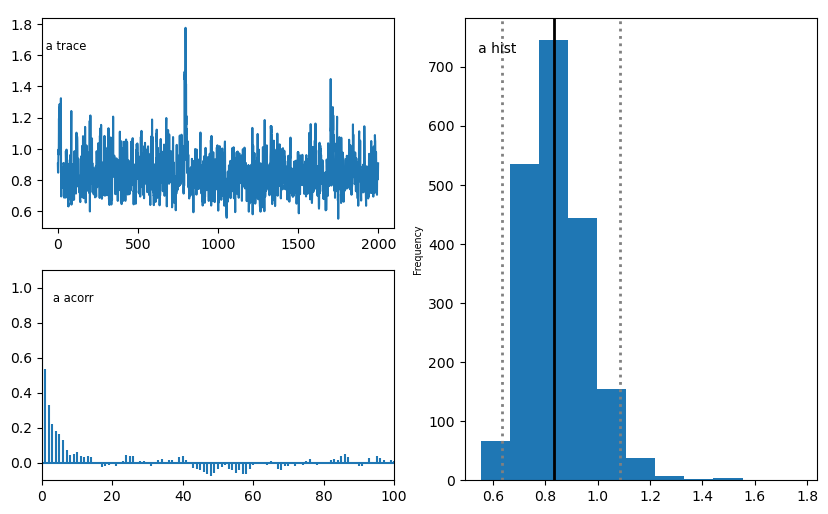

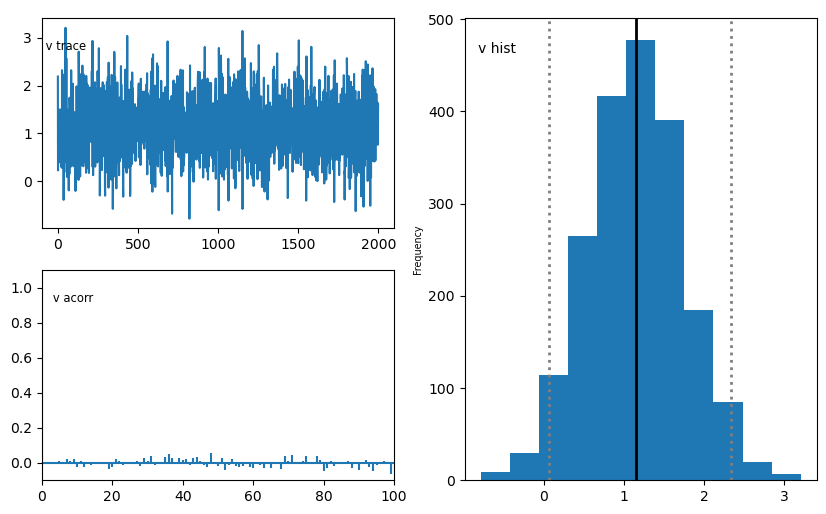

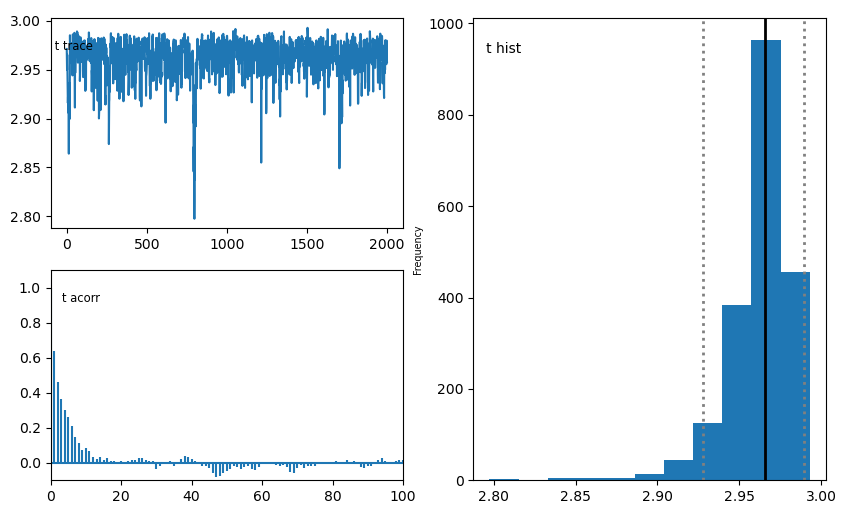

In [10]:
#結果
model.print_stats()          # 各パラメータ（v, a, t など）の事後統計量
model.plot_posteriors()      # 事後分布のプロット（保存される）